<a href="https://colab.research.google.com/github/nicole062797-star/TFM-fin-de-master-Ciencia-de-datos/blob/main/Proceso_de_ETL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Importamos las librerías necesarias para el análisis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
#Configuramos el estilo visual de los gráficos
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
ruta = "/content/drive/MyDrive/Dataset.MuniElCarmen-corte14-04-2026.xlsx"

In [4]:
#Creamos una copia para no modificar el dataset original
df_original = pd.read_excel(ruta, header=1)
df = df_original.copy()

In [5]:
filas_iniciales = df_original.shape[0]
columnas_iniciales = df_original.shape[1]

In [6]:
print("Filas iniciales:", filas_iniciales)
print("Columnas iniciales:", columnas_iniciales)

Filas iniciales: 51013
Columnas iniciales: 17


In [7]:
#Visualizamos datos originales
df_original.head()

,Numero de emision,IDENTIFICACION,PERIODO,TIPO DE POSESION,DESCRIPCION POSESION,CATEGORIA,VALOR,valor poosesion (avaluo/patrimonio),valor de predio emitido 2023,fecha de emision 2023,fecha de liquidacion 2023,valor de predio emitido 2024,fecha de emision 2024,fecha del iquidacion 2024,valor de predio emitido 2025,fecha de emision 2025,fecha de liquidacion 2025
0,2546124,1709466583,Año 2026,PREDIO RUSTICO,130499999900555700000000,Residencial Rural,8.88,80000.00,93.93,2023-01-01,2023-04-03,128.84,2024-01-01,2024-09-13,105.65,2025-01-01,2025-07-08
1,2544809,0100125095,Año 2026,PREDIO RUSTICO,130499999900272900000000,Residencial Rural,8.88,10000.00,28.96,2023-01-01,2024-04-29,23.20,2024-01-01,2024-04-29,23.85,2025-01-01,NaT
2,2591082,0100161744,Año 2026,PREDIO URBANO,1304019602700100000000,Residencial Urbano 2,31.76,207255.03,154.53,2023-01-01,2023-10-03,143.05,2024-01-01,2024-10-25,128.53,2025-01-01,2025-05-05
3,2549128,0100161744,Año 2026,PREDIO RUSTICO,130499999900933000000000,Residencial Rural,8.88,31250.00,6.94,2023-01-01,2023-02-10,6.99,2024-01-01,2024-04-16,7.04,2025-01-01,2025-01-16
4,2577139,0100262948,Año 2026,PREDIO URBANO,1304011308300300000000,Residencial Urbano 3,41.84,153702.57,371.32,2023-01-01,NaT,353.35,2024-01-01,NaT,329.51,2025-01-01,NaT


In [8]:
#Creamos carpetas para guardar evidencias del trabajo
Path("outputs").mkdir(exist_ok=True)
Path("figures").mkdir(exist_ok=True)
Path("data_processed").mkdir(exist_ok=True)

In [9]:
#Visualizamos las primeras filas para revisar la estructura inicial
df_original.head()

,Numero de emision,IDENTIFICACION,PERIODO,TIPO DE POSESION,DESCRIPCION POSESION,CATEGORIA,VALOR,valor poosesion (avaluo/patrimonio),valor de predio emitido 2023,fecha de emision 2023,fecha de liquidacion 2023,valor de predio emitido 2024,fecha de emision 2024,fecha del iquidacion 2024,valor de predio emitido 2025,fecha de emision 2025,fecha de liquidacion 2025
0,2546124,1709466583,Año 2026,PREDIO RUSTICO,130499999900555700000000,Residencial Rural,8.88,80000.00,93.93,2023-01-01,2023-04-03,128.84,2024-01-01,2024-09-13,105.65,2025-01-01,2025-07-08
1,2544809,0100125095,Año 2026,PREDIO RUSTICO,130499999900272900000000,Residencial Rural,8.88,10000.00,28.96,2023-01-01,2024-04-29,23.20,2024-01-01,2024-04-29,23.85,2025-01-01,NaT
2,2591082,0100161744,Año 2026,PREDIO URBANO,1304019602700100000000,Residencial Urbano 2,31.76,207255.03,154.53,2023-01-01,2023-10-03,143.05,2024-01-01,2024-10-25,128.53,2025-01-01,2025-05-05
3,2549128,0100161744,Año 2026,PREDIO RUSTICO,130499999900933000000000,Residencial Rural,8.88,31250.00,6.94,2023-01-01,2023-02-10,6.99,2024-01-01,2024-04-16,7.04,2025-01-01,2025-01-16
4,2577139,0100262948,Año 2026,PREDIO URBANO,1304011308300300000000,Residencial Urbano 3,41.84,153702.57,371.32,2023-01-01,NaT,353.35,2024-01-01,NaT,329.51,2025-01-01,NaT


In [10]:
#Analizamos el tamaño inicial del dataset
df_original.shape

(51013, 17)

In [11]:
#Visualizamos los nombres originales de las columnas
df.columns

Index(['Numero de emision ', 'IDENTIFICACION', 'PERIODO', 'TIPO DE POSESION',
       'DESCRIPCION POSESION', 'CATEGORIA', 'VALOR',
       'valor poosesion (avaluo/patrimonio)', 'valor de predio emitido  2023',
       'fecha de emision 2023', 'fecha de liquidacion 2023',
       'valor de predio emitido  2024', 'fecha de emision 2024',
       'fecha del iquidacion 2024', 'valor de predio emitido  2025',
       'fecha de emision 2025', 'fecha de liquidacion 2025'],
      dtype='object')

In [12]:
#Revisamos los tipos de datos cargados automáticamente
df.dtypes

,0
Numero de emision,int64
IDENTIFICACION,object
PERIODO,object
TIPO DE POSESION,object
DESCRIPCION POSESION,object
CATEGORIA,object
VALOR,float64
valor poosesion (avaluo/patrimonio),float64
valor de predio emitido 2023,float64
fecha de emision 2023,datetime64[ns]


In [13]:
#Limpiamos nombres de columnas para evitar errores
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
    .str.replace("__", "_", regex=False)
    .str.replace("á", "a", regex=False)
    .str.replace("é", "e", regex=False)
    .str.replace("í", "i", regex=False)
    .str.replace("ó", "o", regex=False)
    .str.replace("ú", "u", regex=False)
    .str.replace("ñ", "n", regex=False)
    .str.replace("/", "_", regex=False)
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

In [14]:
#Corregimos nombres que vienen con errores de escritura del Excel
df = df.rename(columns={
    "valor_poosesion_avaluo_patrimonio": "valor_posesion_avaluo_patrimonio",
    "fecha_del_iquidacion_2024": "fecha_de_liquidacion_2024"
})

In [15]:
#Revisamos cómo quedaron las columnas
df.columns

Index(['numero_de_emision', 'identificacion', 'periodo', 'tipo_de_posesion',
       'descripcion_posesion', 'categoria', 'valor',
       'valor_posesion_avaluo_patrimonio', 'valor_de_predio_emitido_2023',
       'fecha_de_emision_2023', 'fecha_de_liquidacion_2023',
       'valor_de_predio_emitido_2024', 'fecha_de_emision_2024',
       'fecha_de_liquidacion_2024', 'valor_de_predio_emitido_2025',
       'fecha_de_emision_2025', 'fecha_de_liquidacion_2025'],
      dtype='object')

In [16]:
#Convertimos las columnas de fechas a formato datetime
columnas_fechas = [
    "fecha_de_emision_2023",
    "fecha_de_liquidacion_2023",
    "fecha_de_emision_2024",
    "fecha_de_liquidacion_2024",
    "fecha_de_emision_2025",
    "fecha_de_liquidacion_2025"
]

for columna in columnas_fechas:
    df[columna] = pd.to_datetime(df[columna], errors="coerce")

df[columnas_fechas].dtypes

,0
fecha_de_emision_2023,datetime64[ns]
fecha_de_liquidacion_2023,datetime64[ns]
fecha_de_emision_2024,datetime64[ns]
fecha_de_liquidacion_2024,datetime64[ns]
fecha_de_emision_2025,datetime64[ns]
fecha_de_liquidacion_2025,datetime64[ns]


In [17]:
#Creamos variables de días hasta liquidación
df["dias_hasta_pago_2023"] = (
    df["fecha_de_liquidacion_2023"] - df["fecha_de_emision_2023"]
).dt.days

df["dias_hasta_pago_2024"] = (
    df["fecha_de_liquidacion_2024"] - df["fecha_de_emision_2024"]
).dt.days

df["dias_hasta_pago_2025"] = (
    df["fecha_de_liquidacion_2025"] - df["fecha_de_emision_2025"]
).dt.days

df[["dias_hasta_pago_2023", "dias_hasta_pago_2024", "dias_hasta_pago_2025"]].describe()

,dias_hasta_pago_2023,dias_hasta_pago_2024,dias_hasta_pago_2025
count,37203.000000,38159.000000,36304.000000
mean,224.559148,163.950339,94.001157
std,278.699841,200.729016,118.578490
min,0.000000,0.000000,0.000000
25%,15.000000,14.000000,13.000000
50%,89.000000,66.000000,33.000000
75%,361.000000,273.000000,135.000000
max,1199.000000,834.000000,468.000000


In [18]:
df_original.describe()

,Numero de emision,VALOR,valor poosesion (avaluo/patrimonio),valor de predio emitido 2023,fecha de emision 2023,fecha de liquidacion 2023,valor de predio emitido 2024,fecha de emision 2024,fecha del iquidacion 2024,valor de predio emitido 2025,fecha de emision 2025,fecha de liquidacion 2025
count,5.101300e+04,51013.000000,5.101300e+04,51013.000000,41974,37203,51013.000000,44669,38159,51013.000000,46699,36304
mean,2.568270e+06,11.301284,2.097338e+04,20.075486,2023-01-05 10:01:52.869871616,2023-08-17 16:32:07.586485248,24.614445,2024-01-03 22:15:52.445767936,2024-06-15 14:11:11.527031552,24.350909,2025-01-02 20:02:24.619798784,2025-04-06 17:50:02.644336640
min,2.542772e+06,8.880000,0.000000e+00,0.000000,2023-01-01 00:00:00,2023-01-03 00:00:00,0.000000,2024-01-01 00:00:00,2024-01-02 00:00:00,0.000000,2025-01-01 00:00:00,2025-01-06 00:00:00
25%,2.555525e+06,8.880000,3.805000e+03,2.460000,2023-01-01 00:00:00,2023-01-17 00:00:00,13.150000,2024-01-01 00:00:00,2024-01-15 00:00:00,13.500000,2025-01-01 00:00:00,2025-01-14 00:00:00
50%,2.568276e+06,8.880000,7.873620e+03,3.600000,2023-01-01 00:00:00,2023-04-05 00:00:00,15.280000,2024-01-01 00:00:00,2024-03-11 00:00:00,14.970000,2025-01-01 00:00:00,2025-02-03 00:00:00
75%,2.581012e+06,10.400000,2.147740e+04,22.800000,2023-01-01 00:00:00,2024-01-04 00:00:00,23.250000,2024-01-01 00:00:00,2024-10-07 00:00:00,22.800000,2025-01-01 00:00:00,2025-05-20 00:00:00
max,2.593759e+06,41.840000,5.589133e+06,4440.380000,2026-04-06 00:00:00,2026-04-14 00:00:00,3365.840000,2026-04-06 00:00:00,2026-04-14 00:00:00,2976.860000,2026-04-08 00:00:00,2026-04-14 00:00:00
std,1.471810e+04,5.554637,5.673517e+04,53.624383,NaN,NaN,52.094034,NaN,NaN,48.177988,NaN,NaN


In [19]:
df_original.describe(include="object")

,IDENTIFICACION,PERIODO,TIPO DE POSESION,DESCRIPCION POSESION,CATEGORIA
count,51013,51013,51013,51013,51013
unique,32941,1,2,50953,4
top,1792835925001,Año 2026,PREDIO RUSTICO,1304015609901600000000,Residencial Rural
freq,394,51013,34009,4,34010


In [20]:
#Guardamos el tamaño inicial
filas_iniciales = df_original.shape[0]
columnas_iniciales = df_original.shape[1]

In [21]:
print("Filas iniciales:", filas_iniciales)
print("Columnas iniciales:", columnas_iniciales)

Filas iniciales: 51013
Columnas iniciales: 17


In [22]:
#Visualizamos los nuevos nombres
df.columns

Index(['numero_de_emision', 'identificacion', 'periodo', 'tipo_de_posesion',
       'descripcion_posesion', 'categoria', 'valor',
       'valor_posesion_avaluo_patrimonio', 'valor_de_predio_emitido_2023',
       'fecha_de_emision_2023', 'fecha_de_liquidacion_2023',
       'valor_de_predio_emitido_2024', 'fecha_de_emision_2024',
       'fecha_de_liquidacion_2024', 'valor_de_predio_emitido_2025',
       'fecha_de_emision_2025', 'fecha_de_liquidacion_2025',
       'dias_hasta_pago_2023', 'dias_hasta_pago_2024', 'dias_hasta_pago_2025'],
      dtype='object')

In [23]:
#Analizamos la cantidad de valores nulos por columna
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100

tabla_nulos = pd.DataFrame({
    "nulos": nulos,
    "porcentaje_nulos": porcentaje_nulos.round(2)
}).sort_values(by="porcentaje_nulos", ascending=False)

tabla_nulos.to_csv("outputs/resumen_nulos.csv")
tabla_nulos

,nulos,porcentaje_nulos
dias_hasta_pago_2025,14709,28.83
fecha_de_liquidacion_2025,14709,28.83
dias_hasta_pago_2023,13810,27.07
fecha_de_liquidacion_2023,13810,27.07
fecha_de_liquidacion_2024,12854,25.20
dias_hasta_pago_2024,12854,25.20
fecha_de_emision_2023,9039,17.72
fecha_de_emision_2024,6344,12.44
fecha_de_emision_2025,4314,8.46
periodo,0,0.00


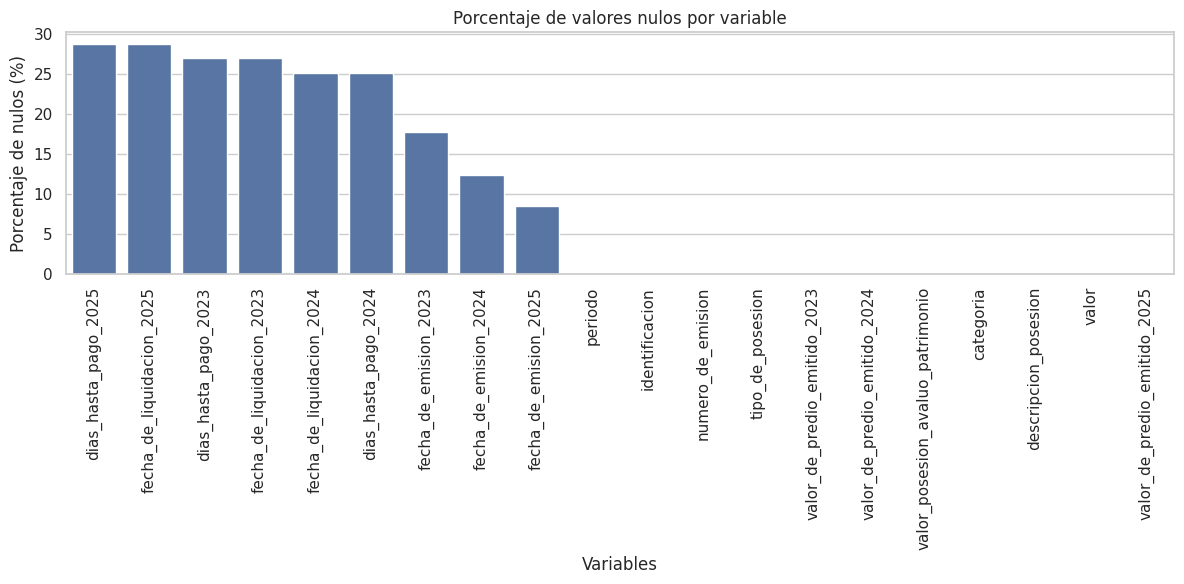

In [24]:
#Visualizamos los valores nulos por columna
plt.figure(figsize=(12,6))
sns.barplot(
    data=tabla_nulos.reset_index(),
    x="index",
    y="porcentaje_nulos"
)


plt.title("Porcentaje de valores nulos por variable")
plt.xlabel("Variables")
plt.ylabel("Porcentaje de nulos (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("figures/01_porcentaje_nulos.png", dpi=300)
plt.show()

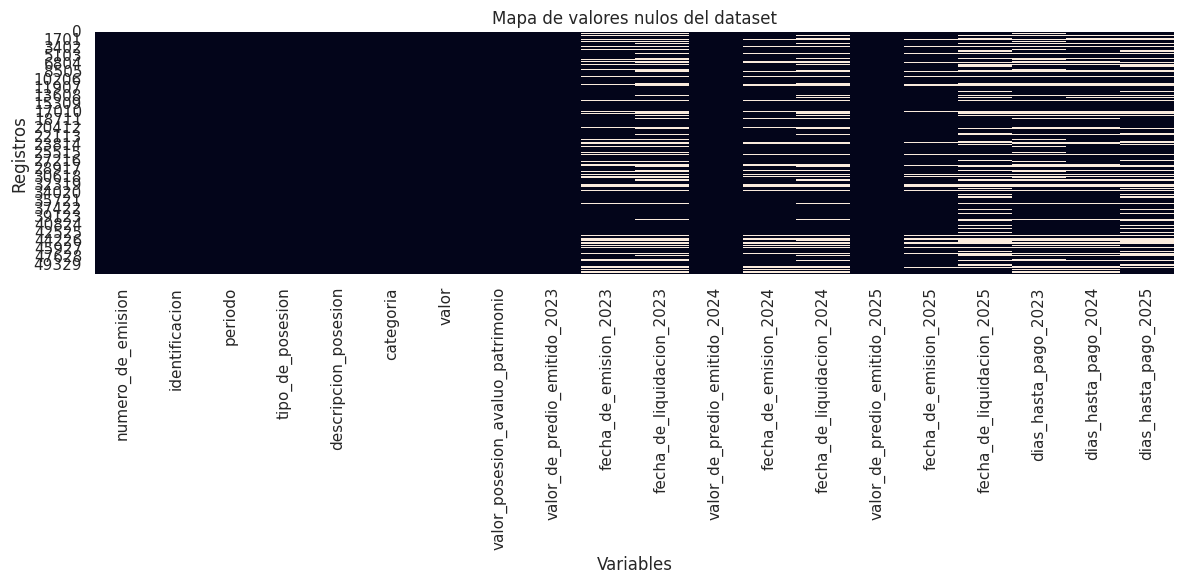

In [25]:
#Creamos un mapa de calor para observar patrones de datos faltantes
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)

plt.title("Mapa de valores nulos del dataset")
plt.xlabel("Variables")
plt.ylabel("Registros")
plt.tight_layout()
plt.savefig("figures/02_mapa_nulos.png", dpi=300)
plt.show()

In [26]:
#Analizamos valores vacíos tipo texto
valores_vacios = (df == "").sum()

tabla_vacios = pd.DataFrame({
    "valores_vacios": valores_vacios
})

tabla_vacios.to_csv("outputs/resumen_valores_vacios.csv")
tabla_vacios

,valores_vacios
numero_de_emision,0
identificacion,0
periodo,0
tipo_de_posesion,0
descripcion_posesion,0
categoria,0
valor,0
valor_posesion_avaluo_patrimonio,0
valor_de_predio_emitido_2023,0
fecha_de_emision_2023,0


In [27]:
# Analizamos registros duplicados
duplicados = df.duplicated().sum()

In [28]:
print("Cantidad de registros duplicados:", duplicados)

Cantidad de registros duplicados: 26


In [29]:
#Guardamos una tabla de auditoría inicial
auditoria = pd.DataFrame({
    "proceso": [
        "Carga inicial",
        "Revisión de nulos",
        "Revisión de vacíos",
        "Revisión de duplicados"
    ],
    "resultado": [
        f"{filas_iniciales} filas y {columnas_iniciales} columnas",
        f"{tabla_nulos['nulos'].sum()} valores nulos identificados",
        f"{tabla_vacios['valores_vacios'].sum()} valores vacíos identificados",
        f"{duplicados} registros duplicados identificados"
    ]
})

auditoria.to_csv("outputs/auditoria_limpieza_inicial.csv", index=False)
auditoria

,proceso,resultado
0,Carga inicial,51013 filas y 17 columnas
1,Revisión de nulos,102443 valores nulos identificados
2,Revisión de vacíos,0 valores vacíos identificados
3,Revisión de duplicados,26 registros duplicados identificados


In [30]:
#Eliminamos duplicados
df_limpio = df.drop_duplicates().copy()

In [31]:
print("Filas antes:", df.shape[0])
print("Filas después:", df_limpio.shape[0])
print("Filas eliminadas:", df.shape[0] - df_limpio.shape[0])

Filas antes: 51013
Filas después: 50987
Filas eliminadas: 26


In [32]:
#Analizamos las columnas tipo object para identificar categorías importantes
columnas_categoricas = df_limpio.select_dtypes(include="object").columns
columnas_categoricas

Index(['identificacion', 'periodo', 'tipo_de_posesion', 'descripcion_posesion',
       'categoria'],
      dtype='object')

In [33]:
# Visualizamos las 10 columnas categóricas con más valores únicos
resumen_categoricas = pd.DataFrame({
    "columna": columnas_categoricas,
    "valores_unicos": [df_limpio[c].nunique() for c in columnas_categoricas]
}).sort_values(by="valores_unicos", ascending=False)

In [34]:
resumen_categoricas.to_csv("outputs/resumen_variables_categoricas.csv", index=False)
resumen_categoricas.head(10)

,columna,valores_unicos
3,descripcion_posesion,50953
0,identificacion,32941
4,categoria,4
2,tipo_de_posesion,2
1,periodo,1


In [35]:
#Variables de estado de pago
df_limpio.loc[:, "estado_pago_2023"] = np.where(
    df_limpio["fecha_de_liquidacion_2023"].isna(),
    "No pagado",
    "Pagado"
)

In [36]:
df_limpio.loc[:, "estado_pago_2024"] = np.where(
    df_limpio["fecha_de_liquidacion_2024"].isna(),
    "No pagado",
    "Pagado"
)

In [37]:
df_limpio.loc[:, "estado_pago_2025"] = np.where(
    df_limpio["fecha_de_liquidacion_2025"].isna(),
    "No pagado",
    "Pagado"
)

In [38]:
#Variables de morosidad
df_limpio.loc[:, "moroso_2023"] = np.where(
    df_limpio["dias_hasta_pago_2023"] > 30,
    1,
    0
)

In [39]:
df_limpio.loc[:, "moroso_2024"] = np.where(
    df_limpio["dias_hasta_pago_2024"] > 30,
    1,
    0
)

In [40]:
df_limpio.loc[:, "moroso_2025"] = np.where(
    df_limpio["dias_hasta_pago_2025"] > 30,
    1,
    0
)

In [41]:
#Variable año
df_limpio.loc[:, "anio"] = (
    df_limpio["periodo"]
    .str.extract(r"(\d+)")
    .astype(float)
)

In [42]:
#Verificamos
df_limpio[[
    "estado_pago_2023", "estado_pago_2024", "estado_pago_2025",
    "moroso_2023", "moroso_2024", "moroso_2025",
    "anio"
]].head()

,estado_pago_2023,estado_pago_2024,estado_pago_2025,moroso_2023,moroso_2024,moroso_2025,anio
0,Pagado,Pagado,Pagado,1,1,1,2026.0
1,Pagado,Pagado,No pagado,1,1,0,2026.0
2,Pagado,Pagado,Pagado,1,1,1,2026.0
3,Pagado,Pagado,Pagado,1,1,0,2026.0
4,No pagado,No pagado,No pagado,0,0,0,2026.0


In [43]:
#Morosidad por tipo de posesión y año
morosidad_tipo_anio = pd.DataFrame({
    "2023": df_limpio.groupby("tipo_de_posesion")["moroso_2023"].mean() * 100,
    "2024": df_limpio.groupby("tipo_de_posesion")["moroso_2024"].mean() * 100,
    "2025": df_limpio.groupby("tipo_de_posesion")["moroso_2025"].mean() * 100
})

morosidad_tipo_anio = morosidad_tipo_anio.round(2)

morosidad_tipo_anio

,2023,2024,2025
tipo_de_posesion,,,
PREDIO RUSTICO,43.03,42.39,34.73
PREDIO URBANO,53.12,48.35,37.33


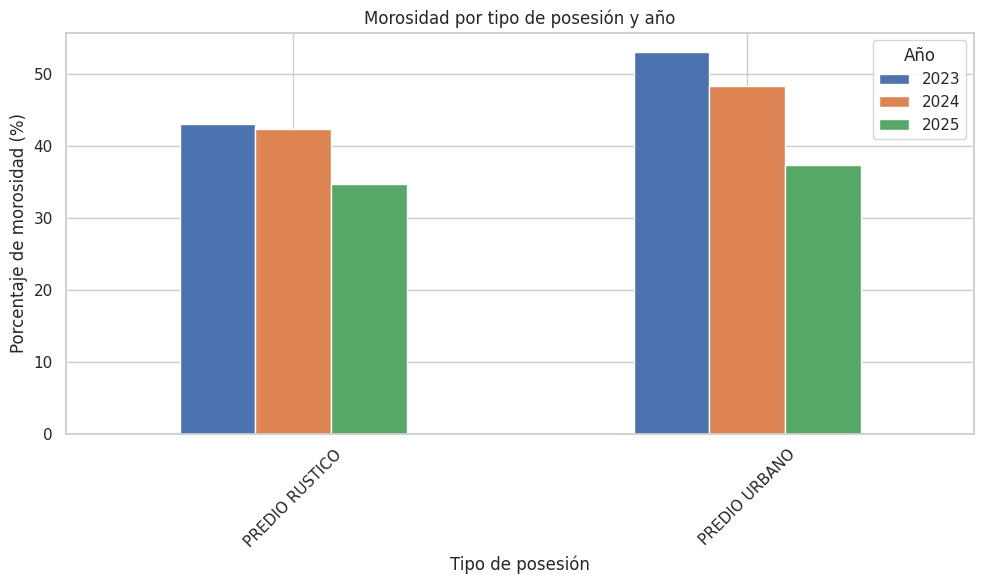

In [44]:
#Visualización de morosidad por tipo y año
morosidad_tipo_anio.plot(kind="bar", figsize=(10,6))

plt.title("Morosidad por tipo de posesión y año")
plt.xlabel("Tipo de posesión")
plt.ylabel("Porcentaje de morosidad (%)")

plt.xticks(rotation=45)
plt.legend(title="Año")

plt.tight_layout()
plt.savefig("figures/11_morosidad_tipo_anio.png", dpi=300)
plt.show()

In [45]:
#Morosidad global por año
morosidad_global = pd.DataFrame({
    "anio": ["2023", "2024", "2025"],
    "morosidad_%": [
        df_limpio["moroso_2023"].mean() * 100,
        df_limpio["moroso_2024"].mean() * 100,
        df_limpio["moroso_2025"].mean() * 100
    ]
})

morosidad_global["morosidad_%"] = morosidad_global["morosidad_%"].round(2)

morosidad_global

,anio,morosidad_%
0,2023,46.39
1,2024,44.37
2,2025,35.60


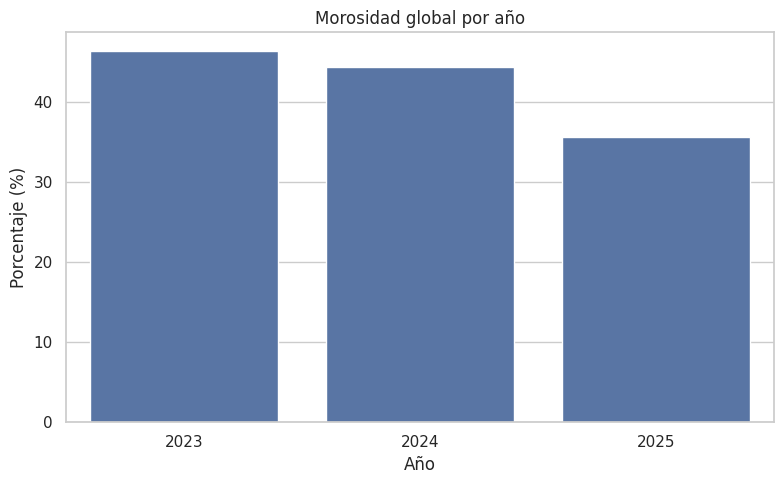

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=morosidad_global,
    x="anio",
    y="morosidad_%"
)

plt.title("Morosidad global por año")
plt.xlabel("Año")
plt.ylabel("Porcentaje (%)")

plt.tight_layout()
plt.savefig("figures/12_morosidad_global.png", dpi=300)

plt.show()

In [47]:
#Guardamos el dataset final
df_limpio.to_csv("data_processed/dataset_etl_final.csv", index=False)

In [48]:
#Visualizamos
print("Dataset final guardado correctamente")
print("Filas finales:", df_limpio.shape[0])
print("Columnas finales:", df_limpio.shape[1])

Dataset final guardado correctamente
Filas finales: 50987
Columnas finales: 27


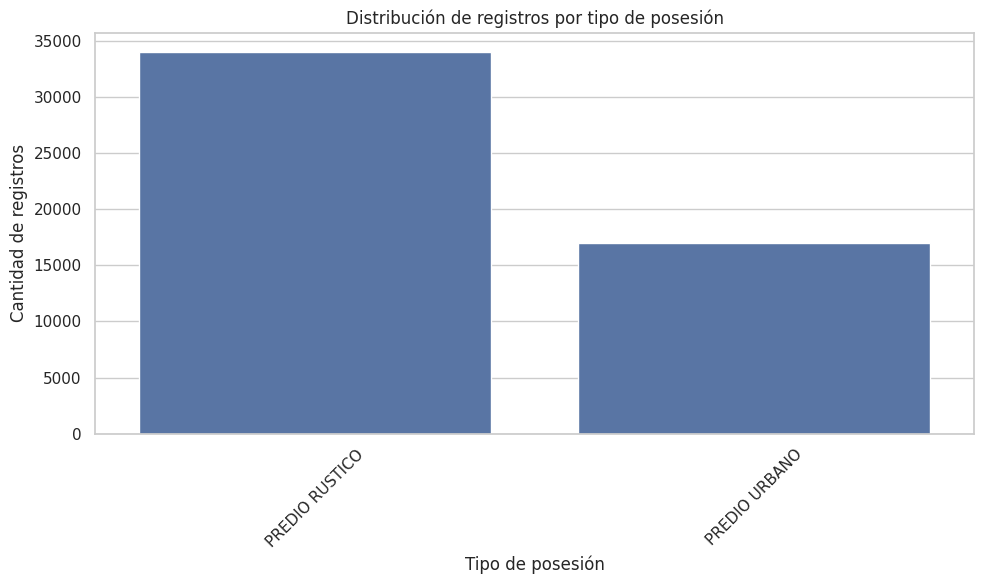

,count
tipo_de_posesion,
PREDIO RUSTICO,33995
PREDIO URBANO,16992


In [49]:
#Gráfico de tipo de posesión
col_tipo = "tipo_de_posesion"

if col_tipo in df_limpio.columns:
    conteo_tipo = df_limpio[col_tipo].value_counts()

    plt.figure(figsize=(10,6))
    sns.barplot(x=conteo_tipo.index, y=conteo_tipo.values)

    plt.title("Distribución de registros por tipo de posesión")
    plt.xlabel("Tipo de posesión")
    plt.ylabel("Cantidad de registros")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("figures/03_tipo_posesion.png", dpi=300)
    plt.show()

    display(conteo_tipo)

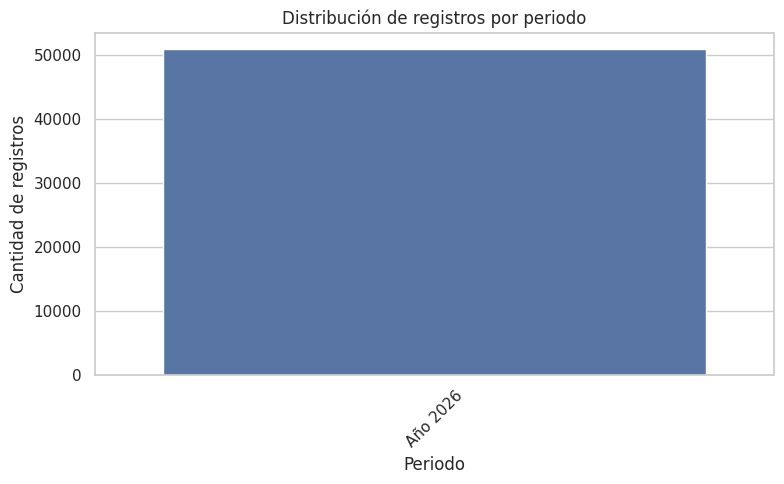

,count
periodo,
Año 2026,50987


In [50]:
#Gráfico de periodo
col_periodo = "periodo"

if col_periodo in df_limpio.columns:
    conteo_periodo = df_limpio[col_periodo].value_counts()

    plt.figure(figsize=(8,5))
    sns.barplot(x=conteo_periodo.index, y=conteo_periodo.values)

    plt.title("Distribución de registros por periodo")
    plt.xlabel("Periodo")
    plt.ylabel("Cantidad de registros")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("figures/04_periodo.png", dpi=300)
    plt.show()

    display(conteo_periodo)

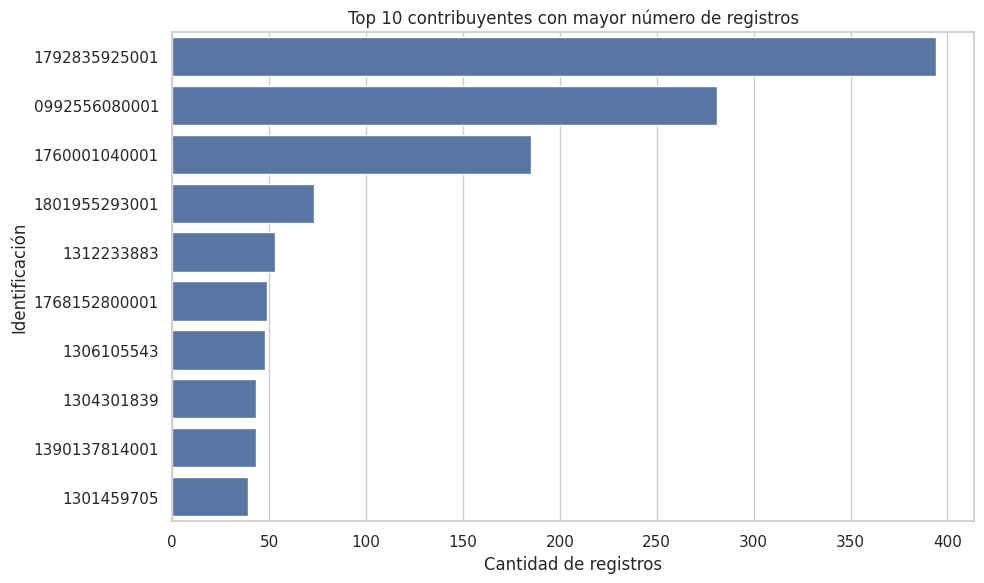

,count
identificacion,
1792835925001,394
0992556080001,281
1760001040001,185
1801955293001,73
1312233883,53
1768152800001,49
1306105543,48
1304301839,43
1390137814001,43


In [51]:
col_identificacion = "identificacion"

if col_identificacion in df_limpio.columns:
    top_contribuyentes = df_limpio[col_identificacion].value_counts().head(10)

    plt.figure(figsize=(10,6))
    sns.barplot(x=top_contribuyentes.values, y=top_contribuyentes.index)

    plt.title("Top 10 contribuyentes con mayor número de registros")
    plt.xlabel("Cantidad de registros")
    plt.ylabel("Identificación")
    plt.tight_layout()
    plt.savefig("figures/05_top_contribuyentes.png", dpi=300)
    plt.show()

    display(top_contribuyentes)

In [52]:
print("Filas finales:", df_limpio.shape[0])
print("Columnas finales:", df_limpio.shape[1])

Filas finales: 50987
Columnas finales: 27


In [53]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50987 entries, 0 to 51012
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   numero_de_emision                 50987 non-null  int64         
 1   identificacion                    50987 non-null  object        
 2   periodo                           50987 non-null  object        
 3   tipo_de_posesion                  50987 non-null  object        
 4   descripcion_posesion              50987 non-null  object        
 5   categoria                         50987 non-null  object        
 6   valor                             50987 non-null  float64       
 7   valor_posesion_avaluo_patrimonio  50987 non-null  float64       
 8   valor_de_predio_emitido_2023      50987 non-null  float64       
 9   fecha_de_emision_2023             41964 non-null  datetime64[ns]
 10  fecha_de_liquidacion_2023         37193 non-null  d

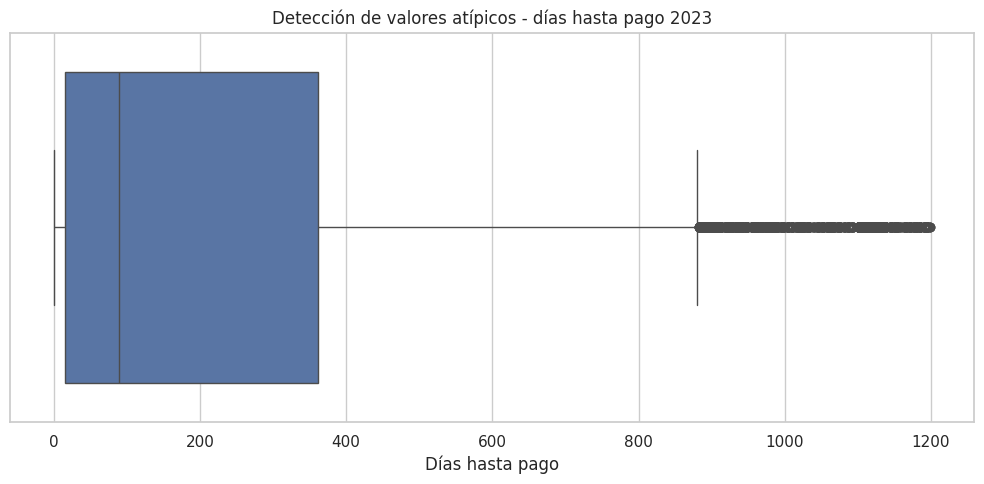

In [54]:
#Gráfico de valores atípicos en días hasta pago
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_limpio["dias_hasta_pago_2023"])

plt.title("Detección de valores atípicos - días hasta pago 2023")
plt.xlabel("Días hasta pago")
plt.tight_layout()
plt.savefig("figures/06_outliers_dias_pago_2023.png", dpi=300)
plt.show()

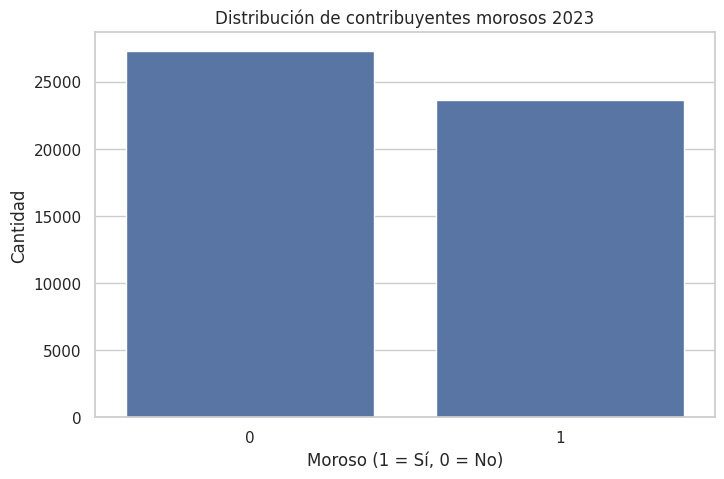

In [55]:
#Gráfico de morosidad
plt.figure(figsize=(8, 5))

sns.countplot(x=df_limpio["moroso_2023"])

plt.title("Distribución de contribuyentes morosos 2023")
plt.xlabel("Moroso (1 = Sí, 0 = No)")
plt.ylabel("Cantidad")

plt.show()

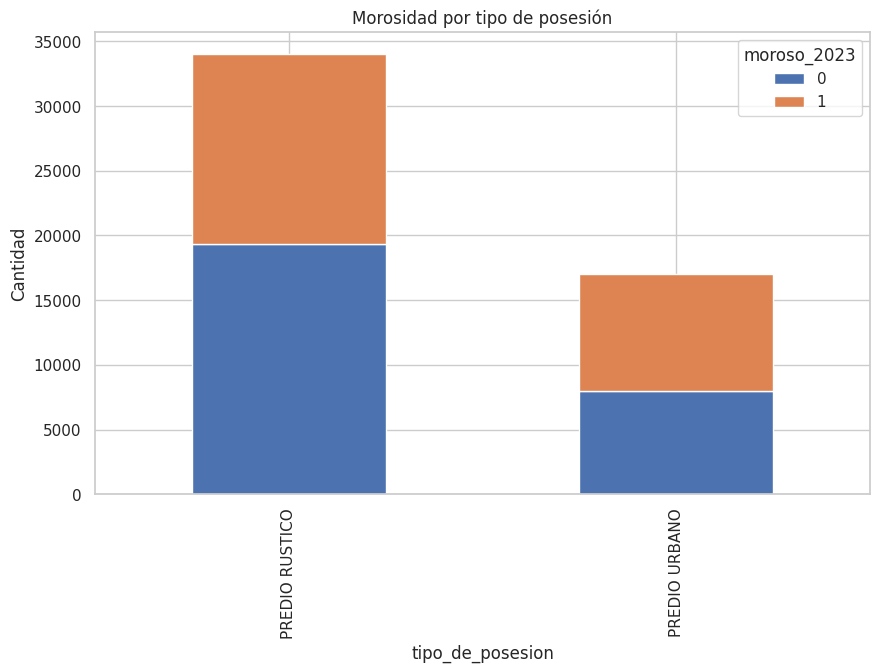

In [56]:
tabla = pd.crosstab(
    df_limpio["tipo_de_posesion"],
    df_limpio["moroso_2023"]
)

tabla.plot(kind="bar", stacked=True)

plt.title("Morosidad por tipo de posesión")
plt.ylabel("Cantidad")

plt.show()

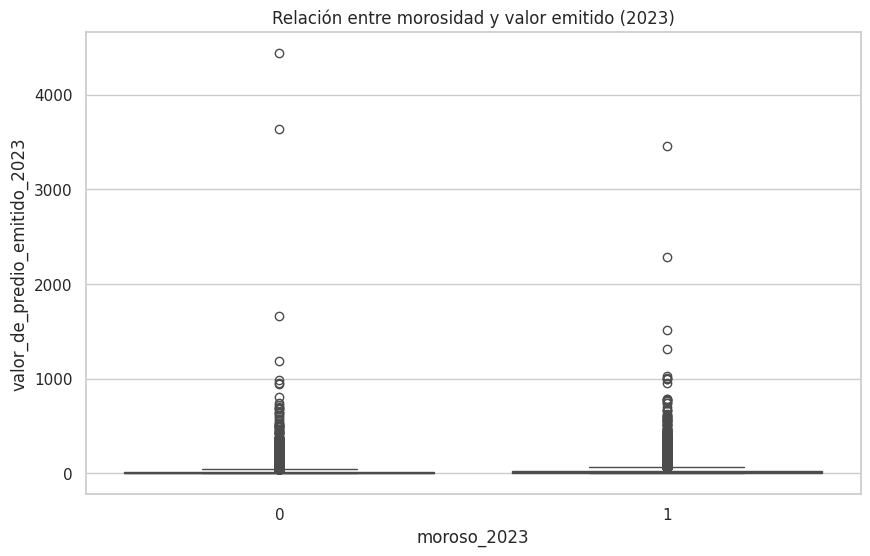

In [57]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="moroso_2023",
    y="valor_de_predio_emitido_2023",
    data=df_limpio
)

plt.title("Relación entre morosidad y valor emitido (2023)")

plt.show()

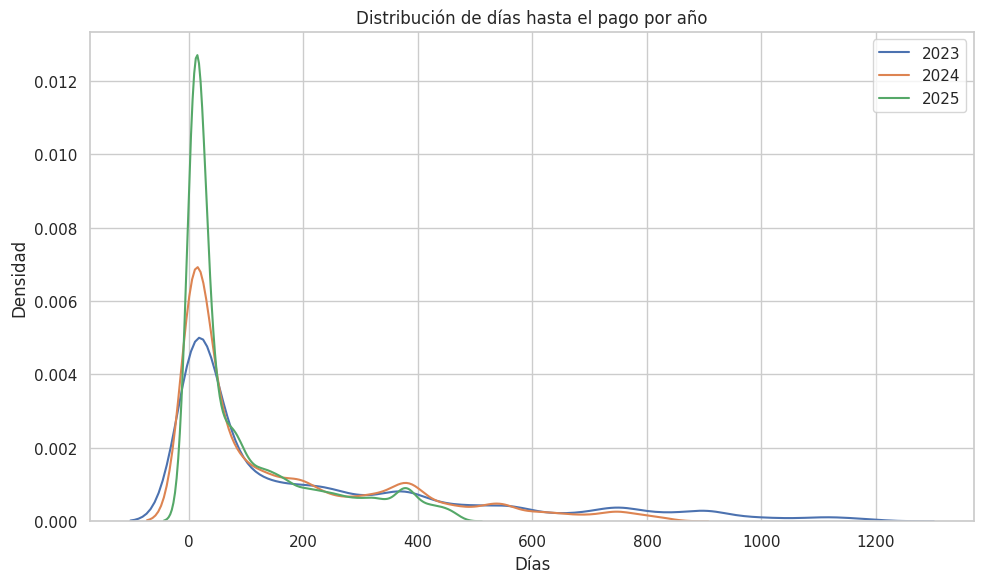

In [58]:
plt.figure(figsize=(10,6))

sns.kdeplot(df_limpio["dias_hasta_pago_2023"].dropna(), label="2023")
sns.kdeplot(df_limpio["dias_hasta_pago_2024"].dropna(), label="2024")
sns.kdeplot(df_limpio["dias_hasta_pago_2025"].dropna(), label="2025")

plt.title("Distribución de días hasta el pago por año")
plt.xlabel("Días")
plt.ylabel("Densidad")

plt.legend()

plt.tight_layout()
plt.savefig("figures/09_distribucion_dias_pago.png", dpi=300)

plt.show()

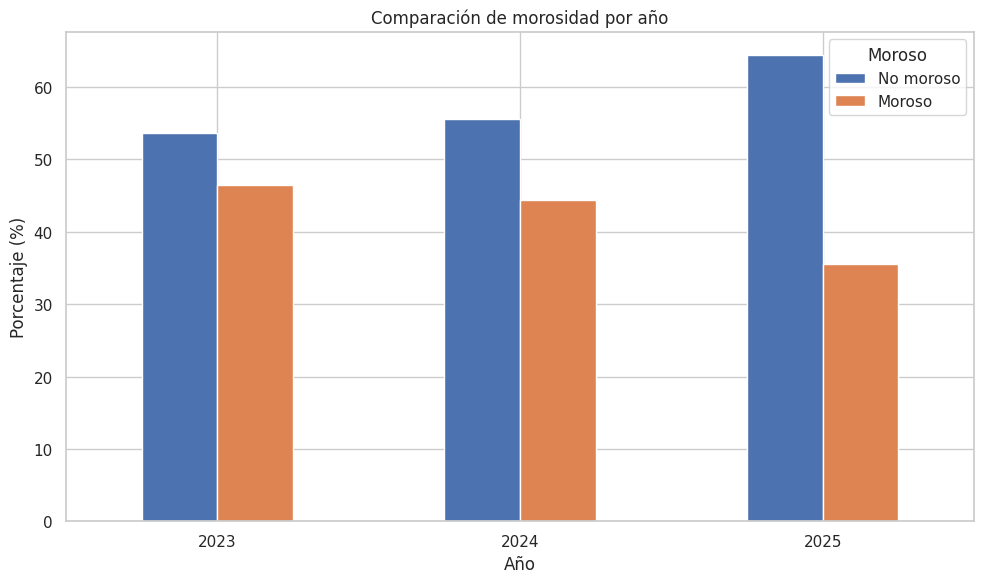

In [59]:
morosidad = pd.DataFrame(index=['No moroso', 'Moroso'])
morosidad['2023'] = df_limpio['moroso_2023'].value_counts(normalize=True).mul(100).rename(index={0: 'No moroso', 1: 'Moroso'})
morosidad['2024'] = df_limpio['moroso_2024'].value_counts(normalize=True).mul(100).rename(index={0: 'No moroso', 1: 'Moroso'})
morosidad['2025'] = df_limpio['moroso_2025'].value_counts(normalize=True).mul(100).rename(index={0: 'No moroso', 1: 'Moroso'})
morosidad = morosidad.T

morosidad.plot(kind="bar")

plt.title("Comparación de morosidad por año")
plt.ylabel("Porcentaje (%)")
plt.xlabel("Año")
plt.xticks(rotation=0)

plt.legend(title="Moroso", labels=["No moroso", "Moroso"])

plt.tight_layout()
plt.savefig("figures/10_morosidad_comparativa.png", dpi=300)

plt.show()

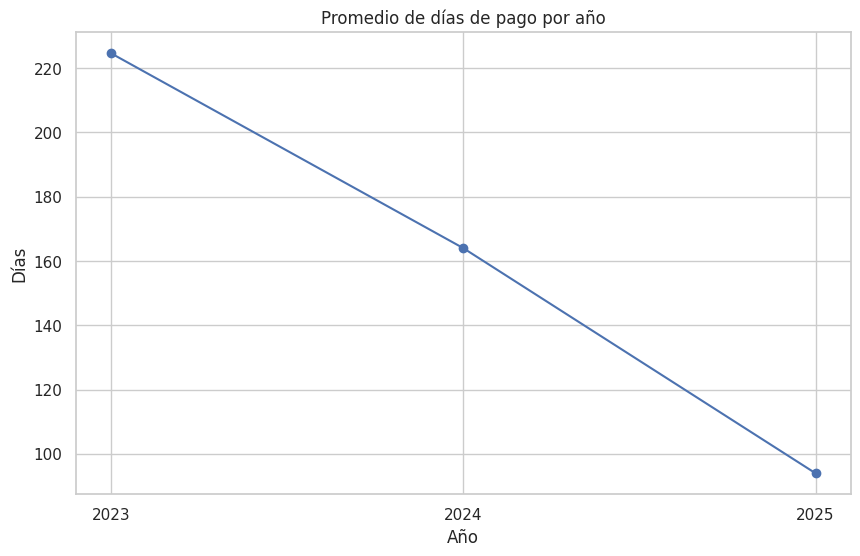

In [60]:
promedios = [
    df_limpio["dias_hasta_pago_2023"].mean(),
    df_limpio["dias_hasta_pago_2024"].mean(),
    df_limpio["dias_hasta_pago_2025"].mean()
]

anios = ["2023", "2024", "2025"]

plt.plot(anios, promedios, marker="o")

plt.title("Promedio de días de pago por año")
plt.xlabel("Año")
plt.ylabel("Días")

plt.show()

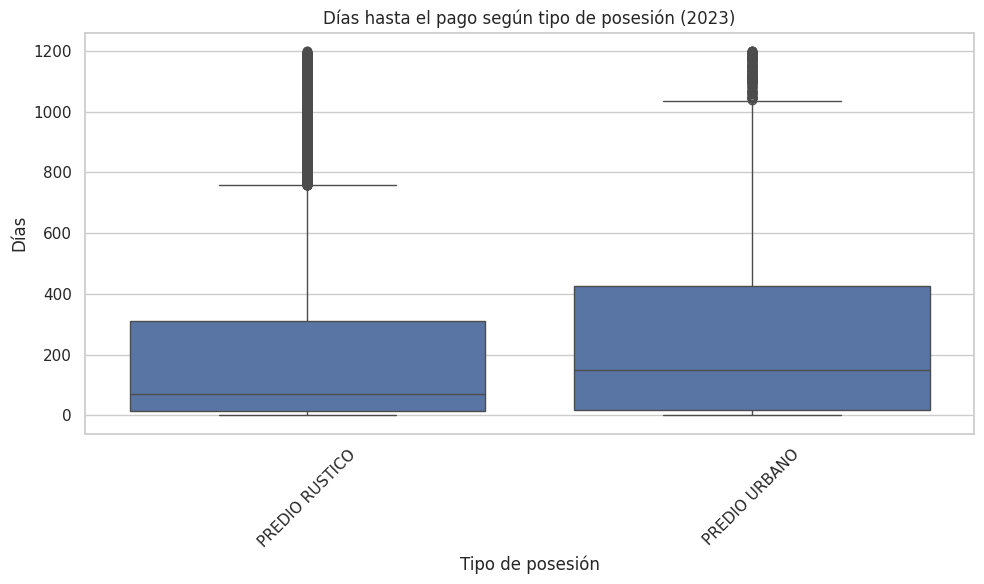

In [61]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="tipo_de_posesion",
    y="dias_hasta_pago_2023",
    data=df_limpio
)

plt.title("Días hasta el pago según tipo de posesión (2023)")
plt.xlabel("Tipo de posesión")
plt.ylabel("Días")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("figures/11_dias_pago_por_tipo.png", dpi=300)

plt.show()

In [62]:
#Dataset final del proceso ETL
df_limpio.to_csv("data_processed/dataset_etl_final.csv", index=False)

In [63]:
print("Filas finales:", df_limpio.shape[0])
print("Columnas finales:", df_limpio.shape[1])

Filas finales: 50987
Columnas finales: 27


In [66]:
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50987 entries, 0 to 51012
Data columns (total 27 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   numero_de_emision                 50987 non-null  int64         
 1   identificacion                    50987 non-null  object        
 2   periodo                           50987 non-null  object        
 3   tipo_de_posesion                  50987 non-null  object        
 4   descripcion_posesion              50987 non-null  object        
 5   categoria                         50987 non-null  object        
 6   valor                             50987 non-null  float64       
 7   valor_posesion_avaluo_patrimonio  50987 non-null  float64       
 8   valor_de_predio_emitido_2023      50987 non-null  float64       
 9   fecha_de_emision_2023             41964 non-null  datetime64[ns]
 10  fecha_de_liquidacion_2023         37193 non-null  d